/home/css/myenv/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


开始训练: P=97, Train Size=4704, Device=cuda
Epoch    0 | Train Acc: 0.0087 | Test Acc: 0.0068
Epoch   20 | Train Acc: 0.3841 | Test Acc: 0.0446
Epoch   40 | Train Acc: 0.9928 | Test Acc: 0.4976
Epoch   60 | Train Acc: 1.0000 | Test Acc: 0.5007
Epoch   80 | Train Acc: 1.0000 | Test Acc: 0.5018
Epoch  100 | Train Acc: 1.0000 | Test Acc: 0.5024
Epoch  120 | Train Acc: 1.0000 | Test Acc: 0.5044
Epoch  140 | Train Acc: 1.0000 | Test Acc: 0.5073
Epoch  160 | Train Acc: 1.0000 | Test Acc: 0.5207
Epoch  180 | Train Acc: 1.0000 | Test Acc: 0.6918
Epoch  200 | Train Acc: 1.0000 | Test Acc: 0.7921
Epoch  220 | Train Acc: 1.0000 | Test Acc: 0.9452
Epoch  240 | Train Acc: 1.0000 | Test Acc: 0.9974
模型已完全泛化 (Grokking)！


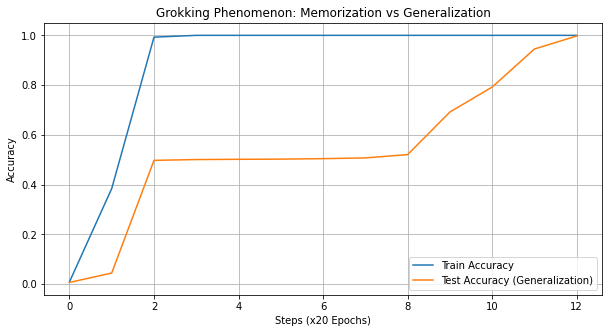

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import random
import math
import matplotlib.pyplot as plt

# ===========================
# 1. 超参数设置
# ===========================
P = 97          # 模数 (质数效果最好)
D_MODEL = 128   # 嵌入维度
N_HEAD = 4      # 注意力头数
N_LAYER = 1     # Transformer层数
LR = 1e-3       # 学习率
BATCH_SIZE = 512
EPOCHS = 2000    # 需要较多轮次才能观察到 Grokking
TRAIN_RATIO = 0.5 # 训练集比例 (50%用于训练，50%用于测试泛化)
SEED = 42

# 设置随机种子
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ===========================
# 2. 数据集生成
# ===========================
def generate_data(p):
    """生成所有可能的加法对 (a, b) -> (a + b) % p"""
    inputs = []
    targets = []
    for x in range(p):
        for y in range(p):
            inputs.append([x, y])
            targets.append((x + y) % p)
    return torch.tensor(inputs), torch.tensor(targets)

data_x, data_y = generate_data(P)

# 划分训练集和测试集
total_samples = len(data_x)
train_size = int(total_samples * TRAIN_RATIO)
indices = torch.randperm(total_samples)

train_idx = indices[:train_size]
test_idx = indices[train_size:]

train_dataset = TensorDataset(data_x[train_idx], data_y[train_idx])
test_dataset = TensorDataset(data_x[test_idx], data_y[test_idx])

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

# ===========================
# 3. Transformer 模型架构
# ===========================
class ModularAdder(nn.Module):
    def __init__(self, p, d_model, n_head, n_layer):
        super().__init__()
        self.d_model = d_model
        
        # 1. Token Embeddings (词表大小为 p, 输入数字即为索引)
        self.token_emb = nn.Embedding(p, d_model)
        
        # 2. Positional Embeddings (输入长度固定为 2: [a, b])
        self.pos_emb = nn.Parameter(torch.randn(1, 2, d_model) * 0.02)
        
        # 3. Transformer Encoder (这里不需要Mask，因为输入都可见)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=d_model * 4, 
            dropout=0.0,
            activation='relu',
            batch_first=True,
            norm_first=True # Pre-LN 通常更稳定
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        
        # 4. Layer Norm & Decoder Head
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, p, bias=False) # 输出 logits 对应 0..p-1

    def forward(self, idx):
        # idx shape: (batch, 2)
        b, t = idx.size()
        
        # Token + Pos Embedding
        x = self.token_emb(idx) # (batch, 2, d_model)
        x = x + self.pos_emb    # 广播加法
        
        # Transformer 处理
        x = self.transformer(x) # (batch, 2, d_model)
        
        # 我们取所有token的平均值或者只取最后一个token来做预测
        # 这里采用取平均池化 (Mean Pooling) 策略，这在算法任务中常用
        x = x.mean(dim=1) # (batch, d_model)
        
        x = self.ln_f(x)
        logits = self.head(x) # (batch, p)
        return logits

model = ModularAdder(P, D_MODEL, N_HEAD, N_LAYER).to(device)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1.0) # Weight decay 对 Grokking 很重要
criterion = nn.CrossEntropyLoss()

# ===========================
# 4. 训练循环
# ===========================
print(f"开始训练: P={P}, Train Size={len(train_dataset)}, Device={device}")
history = {'train_acc': [], 'test_acc': []}

try:
    for epoch in range(EPOCHS):
        model.train()
        correct = 0
        total = 0
        
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            
            pred = logits.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += y.size(0)
            
        train_acc = correct / total
        
        # 验证
        if epoch % 20 == 0:
            model.eval()
            with torch.no_grad():
                # 取出全量测试集
                x_test, y_test = next(iter(test_loader))
                x_test, y_test = x_test.to(device), y_test.to(device)
                logits_test = model(x_test)
                pred_test = logits_test.argmax(dim=-1)
                test_acc = (pred_test == y_test).float().mean().item()
                
            history['train_acc'].append(train_acc)
            history['test_acc'].append(test_acc)
            
            print(f"Epoch {epoch:4d} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
            
            # 提前停止：如果完全泛化
            if test_acc > 0.99:
                print("模型已完全泛化 (Grokking)！")
                break

except KeyboardInterrupt:
    print("训练手动停止")

# ===========================
# 5. 结果可视化
# ===========================
plt.figure(figsize=(10, 5))
plt.plot(history['train_acc'], label="Train Accuracy")
plt.plot(history['test_acc'], label="Test Accuracy")
plt.xlabel("steps)")
plt.ylabel("accuracy")
plt.title("Grokking")
plt.legend()
plt.grid(True)
plt.show()

/home/css/myenv/lib/python3.8/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


Using device: cuda

=== Training for n=2 terms ===
Generating full dataset for p=13, n=2 (Total size: 169)...
Total samples: 169
Training samples: 84 (Ratio: 0.4970)
Validation samples: 85


n=2: 100%|██████████| 100000/100000 [17:04<00:00, 97.62it/s, tr_acc=1.00, val_acc=0.66] 


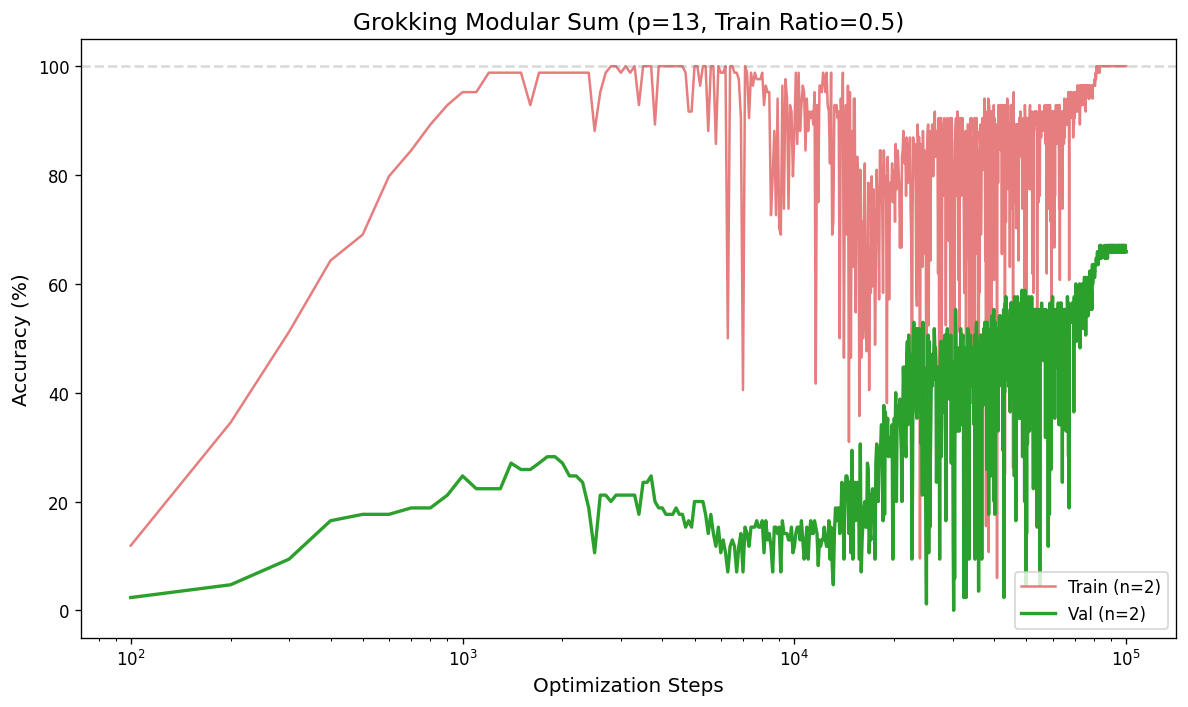

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import itertools

# ==========================================
# 1. 模型定义 (Transformer)
# ==========================================

class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=16, n_head=2, n_layer=1, max_len=50, dropout=0.0):
        super().__init__()
        self.d_model = d_model
        
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.register_buffer("pe", self._position_encoding(max_len, d_model))
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_head, 
            dim_feedforward=4*d_model, 
            dropout=dropout,
            activation='relu',
            norm_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layer)
        self.layer_norm = nn.LayerNorm(d_model)
        self.fc_out = nn.Linear(d_model, vocab_size, bias=False)

    def _position_encoding(self, max_len, d_model):
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)

    def forward(self, x):
        seq_len = x.size(1)
        mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device) * float('-inf'), diagonal=1)
        x_emb = self.embedding(x) * math.sqrt(self.d_model)
        x_emb = x_emb + self.pe[:, :seq_len, :]
        out = self.transformer_encoder(x_emb.transpose(0, 1), mask=mask)
        out = out.transpose(0, 1)
        out = self.layer_norm(out)
        logits = self.fc_out(out)
        return logits

# ==========================================
# 2. 全排列数据集 (Full Permutation Dataset)
# ==========================================

class FullModularDataset(Dataset):
    def __init__(self, p=97, n_terms=2):
        """
        生成完整的运算表。
        对于 n_terms=2, 数据量为 p^2。
        对于 n_terms=3, 数据量为 p^3。
        """
        self.p = p
        self.n_terms = n_terms
        self.plus_token = p
        self.eq_token = p + 1
        self.vocab_size = p + 2
        
        # 1. 生成所有可能的输入组合 (Cartesian Product)
        # 例如 n=2, p=97 -> shape (9409, 2)
        print(f"Generating full dataset for p={p}, n={n_terms} (Total size: {p**n_terms})...")
        ranges = [torch.arange(p) for _ in range(n_terms)]
        self.inputs = torch.cartesian_prod(*ranges) 
        
        # 2. 计算目标值
        self.targets = self.inputs.sum(dim=1) % p
        
        # 3. 构建 Token 序列 [a, +, b, =, ?]
        # 序列长度: 数字个数(n) + 加号个数(n-1) + 等号(1) = 2*n
        # 实际上为了简单，我们通常构造 [a, +, b, =] (长度 2*n)
        # 预测的目标是 target
        
        N = self.inputs.size(0)
        seq_len = 2 * n_terms
        self.sequences = torch.zeros((N, seq_len), dtype=torch.long)
        
        # 填入数字: 偶数索引 0, 2, 4...
        for i in range(n_terms):
            self.sequences[:, 2*i] = self.inputs[:, i]
            
        # 填入加号: 奇数索引 1, 3... (除最后一个)
        # 填入等号: 最后一个索引 -1
        # 先把所有奇数位置填成 +, 然后把最后一个修正为 =
        # 只有当 n_terms >= 1 时才有效
        if seq_len > 1:
            self.sequences[:, 1::2] = self.plus_token
            self.sequences[:, -1] = self.eq_token
            
    def __len__(self):
        return self.sequences.size(0)

    def __getitem__(self, idx):
        return self.sequences[idx], self.targets[idx]

# ==========================================
# 3. 训练函数
# ==========================================

def run_experiment(n_terms_list, p=97, train_ratio=0.5, steps=30000, batch_size=1024, max_train_samples=10000):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    results = {}

    for n in n_terms_list:
        print(f"\n=== Training for n={n} terms ===")
        
        full_ds = FullModularDataset(p=p, n_terms=n)
        
        # === 关键修改逻辑 ===
        total_len = len(full_ds)
        
        # 如果是 n=2，数据少，可以用 50%
        # 如果是 n=3，数据多，强制限制训练集数量，例如最多只用 10,000 条
        if total_len * train_ratio > max_train_samples:
            train_len = max_train_samples
            print(f"Dataset too large, limiting training samples to {train_len}")
        else:
            train_len = int(total_len * train_ratio)
            
        val_len = total_len - train_len
        
        print(f"Total samples: {total_len}")
        print(f"Training samples: {train_len} (Ratio: {train_len/total_len:.4f})")
        print(f"Validation samples: {val_len}")
        
        # 固定随机种子以确保可复现性
        generator = torch.Generator().manual_seed(42)
        train_ds, test_ds = torch.utils.data.random_split(full_ds, [train_len, val_len], generator=generator)
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
        
        model = Transformer(vocab_size=full_ds.vocab_size).to(device)
        # 关键参数: Weight Decay = 1.0 (Grokking 核心)
        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0, betas=(0.9, 0.98))
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=steps)
        
        history = {'step': [], 'val_acc': [], 'train_acc': []}
        step_count = 0
        pbar = tqdm(total=steps, desc=f"n={n}")
        
        while step_count < steps:
            for x, y in train_loader:
                if step_count >= steps: break
                
                model.train()
                x, y = x.to(device), y.to(device)
                
                optimizer.zero_grad()
                logits = model(x)
                last_token_logits = logits[:, -1, :] 
                loss = F.cross_entropy(last_token_logits, y)
                
                loss.backward()
                optimizer.step()
                scheduler.step()
                step_count += 1
                
                # 记录数据 (为了速度，每100步记录一次)
                if step_count % 100 == 0:
                    # 估算训练准确率 (当前batch)
                    with torch.no_grad():
                        train_pred = last_token_logits.argmax(dim=-1)
                        train_acc = (train_pred == y).float().mean().item()
                    
                    # 计算验证集准确率 (全量)
                    # 注意: 如果 p^3 很大，验证集可能很大，可以考虑只采样验证
                    model.eval()
                    correct = 0
                    total = 0
                    with torch.no_grad():
                        for tx, ty in test_loader:
                            tx, ty = tx.to(device), ty.to(device)
                            out = model(tx)
                            pred = out[:, -1, :].argmax(dim=-1)
                            correct += (pred == ty).sum().item()
                            total += ty.size(0)
                    val_acc = correct / total
                    
                    history['step'].append(step_count)
                    history['train_acc'].append(train_acc)
                    history['val_acc'].append(val_acc)
                    
                    pbar.set_postfix({'tr_acc': f"{train_acc:.2f}", 'val_acc': f"{val_acc:.2f}"})
                    pbar.update(100)
        
        results[n] = history
        pbar.close()
        
    return results

# ==========================================
# 4. 执行与绘图
# ==========================================

if __name__ == "__main__":
    # 参数设置
    P = 13
    N_TERMS_LIST = [2]  # 可以尝试 [2, 3]，注意 n=3 时数据量是 97^3 ~ 100万
    STEPS = 100000       # 为了看到 Grokking，建议 2w+, 最好 10w
    TRAIN_RATIO = 0.5   # 50% 数据用于训练
    
    experiment_results = run_experiment(N_TERMS_LIST, p=P, train_ratio=TRAIN_RATIO, steps=STEPS)

    # 绘图
    plt.figure(figsize=(10, 6), dpi=120)
    
    for n, hist in experiment_results.items():
        steps = hist['step']
        train_acc = np.array(hist['train_acc']) * 100
        val_acc = np.array(hist['val_acc']) * 100
        
        # 训练曲线 (红色)
        plt.plot(steps, train_acc, 
                 label=f'Train (n={n})', color='#d62728', linestyle='-', alpha=0.6)
        
        # 验证曲线 (绿色)
        plt.plot(steps, val_acc, 
                 label=f'Val (n={n})', color='#2ca02c', linestyle='-', linewidth=2)

    plt.xscale('log') # 对数坐标
    plt.xlabel('Optimization Steps', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.title(f'Grokking Modular Sum (p={P}, Train Ratio={TRAIN_RATIO})', fontsize=14)
    plt.legend(loc='lower right')
    plt.ylim(-5, 105)
    plt.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

开始双重分析 (Min Sample m & Min Eigenvalue)...
正在计算 p=17...
正在计算 p=23...


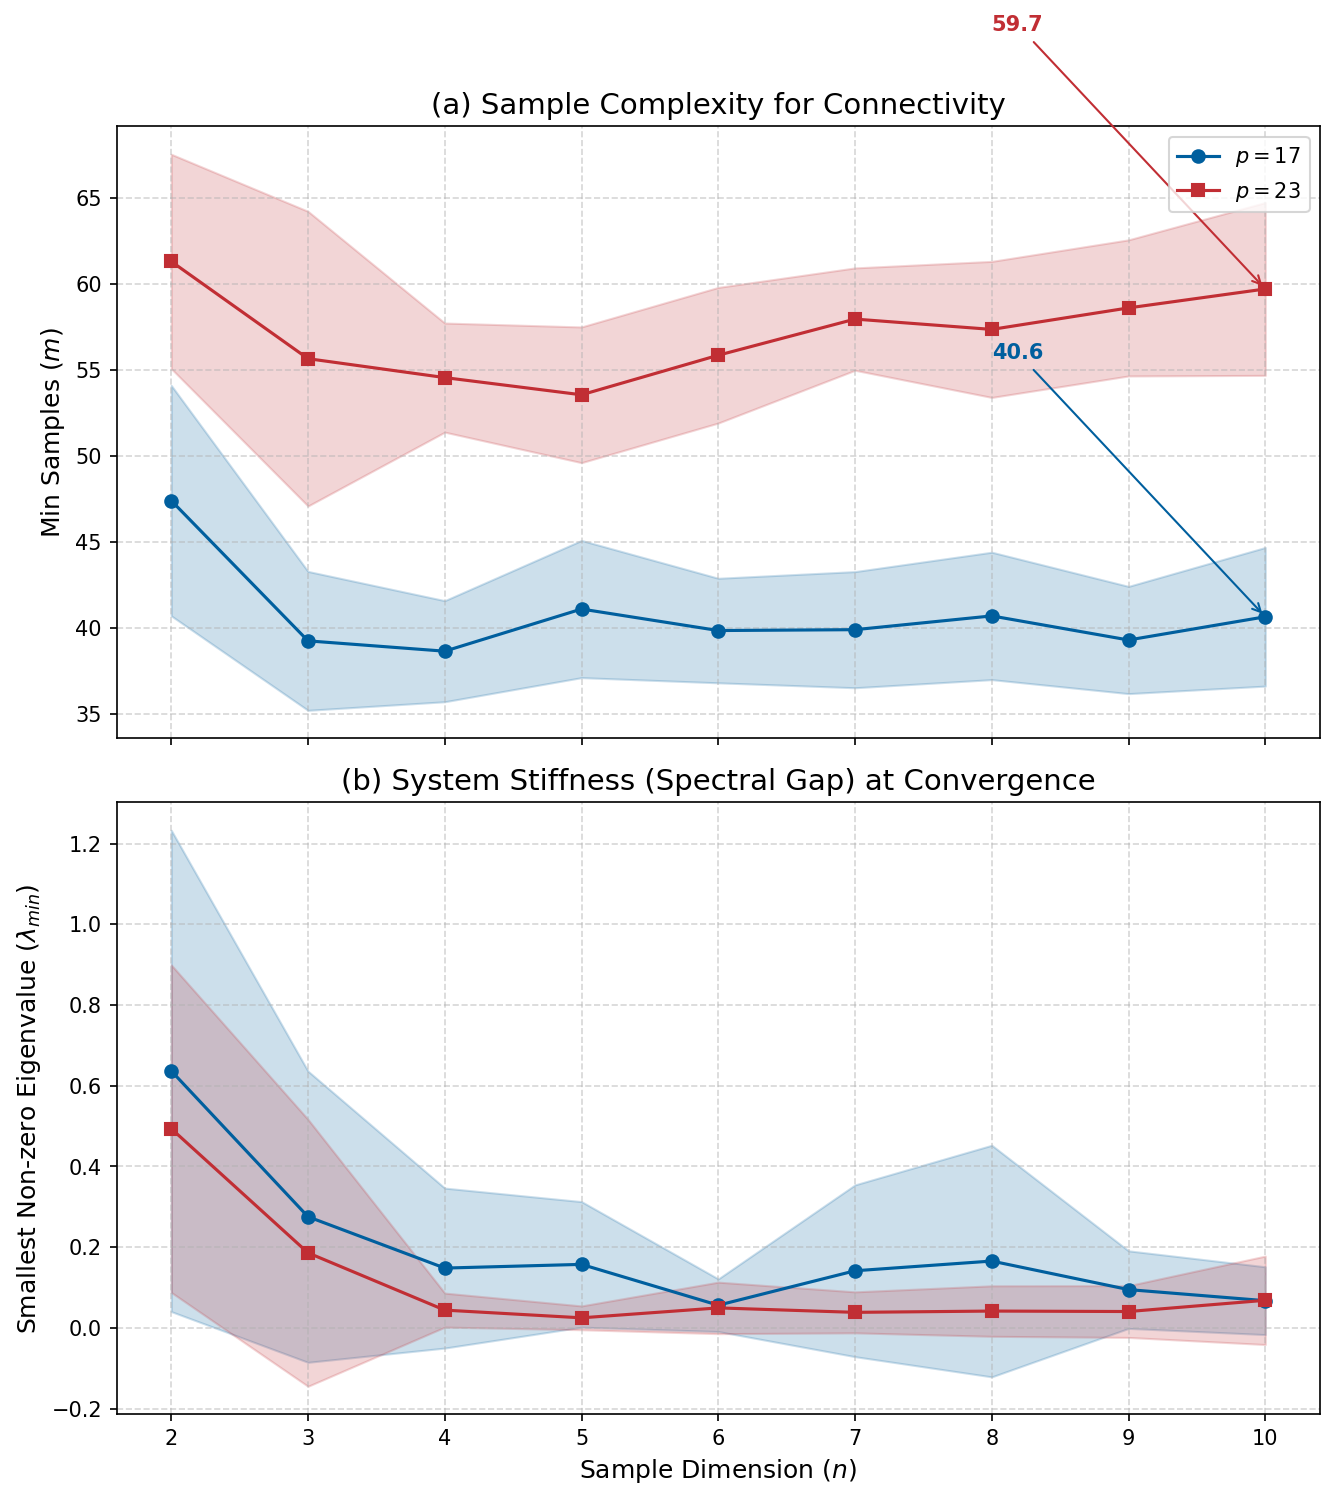

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import sys

# 防止深度递归报错
sys.setrecursionlimit(5000)

def simulate_m_and_lambda(p, n, target_rank, max_m_limit=1000):
    """
    寻找最小的 m 使得 Hessian 秩达到 target_rank。
    同时返回该时刻的最小非零特征值。
    """
    if n > p: raise ValueError("n must be <= p")

    # 存储样本与分组
    # S = [] # (优化：不需要存原始S，只需要groups)
    groups = defaultdict(list)
    
    for m in range(1, max_m_limit + 1):
        # 无放回采样
        new_sample = np.random.choice(p, size=n, replace=False)
        s_sum = np.sum(new_sample)
        groups[s_sum].append(new_sample)
        
        # 优化：m 太小时跳过计算
        if m < target_rank: continue
            
        # 构建 Hessian
        H_total = np.zeros((p, p))
        
        for g_sum, group in groups.items():
            a = len(group)
            if a < 2: continue
            
            # 链式配对
            for i in range(a):
                s1 = group[i]
                s2 = group[(i + 1) % a]
                
                c = np.zeros(p)
                np.add.at(c, s1, 1)
                np.add.at(c, s2, -1)
                H_total += 2 * np.outer(c, c)
        
        # 计算特征值
        eigvals = np.linalg.eigvalsh(H_total)
        # 排序：从小到大
        eigvals.sort()
        
        # 理论上 eigvals[0] 和 eigvals[1] 应该是 0 (对应全1向量和梯度向量)
        # 我们检查非零特征值的数量
        non_zeros = eigvals[eigvals > 1e-5]
        
        if len(non_zeros) >= target_rank:
            # 找到了临界点！
            # 最小非零特征值即为 non_zeros 的第一个元素
            min_lambda = non_zeros[0]
            return m, min_lambda
            
    return max_m_limit, 0.0

def run_dual_analysis():
    p_list = [17, 23]
    trials = 20
    
    data = {}
    
    print("开始双重分析 (Min Sample m & Min Eigenvalue)...")
    
    for p in p_list:
        target_rank = p - 2
        
        # 采样点设置
        n_values_raw = list(range(2, 11))
        n_values = sorted(list(set([n for n in n_values_raw if n <= p])))
        
        means_m = []
        stds_m = []
        means_lam = []
        stds_lam = []
        
        print(f"正在计算 p={p}...")
        
        for n in n_values:
            m_batch = []
            lam_batch = []
            
            for _ in range(trials):
                m_val, lam_val = simulate_m_and_lambda(p, n, target_rank)
                m_batch.append(m_val)
                lam_batch.append(lam_val)
            
            means_m.append(np.mean(m_batch))
            stds_m.append(np.std(m_batch))
            means_lam.append(np.mean(lam_batch))
            stds_lam.append(np.std(lam_batch))
            
        data[p] = {
            'n': np.array(n_values),
            'mean_m': np.array(means_m),
            'std_m': np.array(stds_m),
            'mean_lam': np.array(means_lam),
            'std_lam': np.array(stds_lam)
        }
    
    return data

def plot_dual_results(data):
    # 创建 2 个子图，垂直排列
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 10), dpi=150, sharex=True)
    
    styles = {
        17: {'color': '#005f9e', 'marker': 'o', 'label': r'$p=17$'},
        23: {'color': '#c12e34', 'marker': 's', 'label': r'$p=23$'}
    }
    
    # --- 子图 1: 最小样本数 m ---
    for p, d in data.items():
        style = styles[p]
        ax1.plot(d['n'], d['mean_m'], 
                 color=style['color'], marker=style['marker'], label=style['label'])
        ax1.fill_between(d['n'], d['mean_m'] - d['std_m'], d['mean_m'] + d['std_m'], 
                         color=style['color'], alpha=0.2)
        
        # 标注终点
        ax1.annotate(f"{d['mean_m'][-1]:.1f}", 
                     xy=(d['n'][-1], d['mean_m'][-1]), 
                     xytext=(d['n'][-1]-2, d['mean_m'][-1]+15),
                     arrowprops=dict(arrowstyle="->", color=style['color']),
                     color=style['color'], fontweight='bold')

    ax1.set_ylabel(r'Min Samples ($m$)', fontsize=12)
    ax1.set_title(r'(a) Sample Complexity for Connectivity', fontsize=14)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend()

    # --- 子图 2: 最小非零特征值 lambda_min ---
    for p, d in data.items():
        style = styles[p]
        ax2.plot(d['n'], d['mean_lam'], 
                 color=style['color'], marker=style['marker'], label=style['label'])
        ax2.fill_between(d['n'], d['mean_lam'] - d['std_lam'], d['mean_lam'] + d['std_lam'], 
                         color=style['color'], alpha=0.2)
        

    ax2.set_ylabel(r'Smallest Non-zero Eigenvalue ($\lambda_{min}$)', fontsize=12)
    ax2.set_xlabel(r'Sample Dimension ($n$)', fontsize=12)
    ax2.set_title(r'(b) System Stiffness (Spectral Gap) at Convergence', fontsize=14)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# 运行
res_data = run_dual_analysis()
plot_dual_results(res_data)

Plot saved to grokking_dual_curves.png


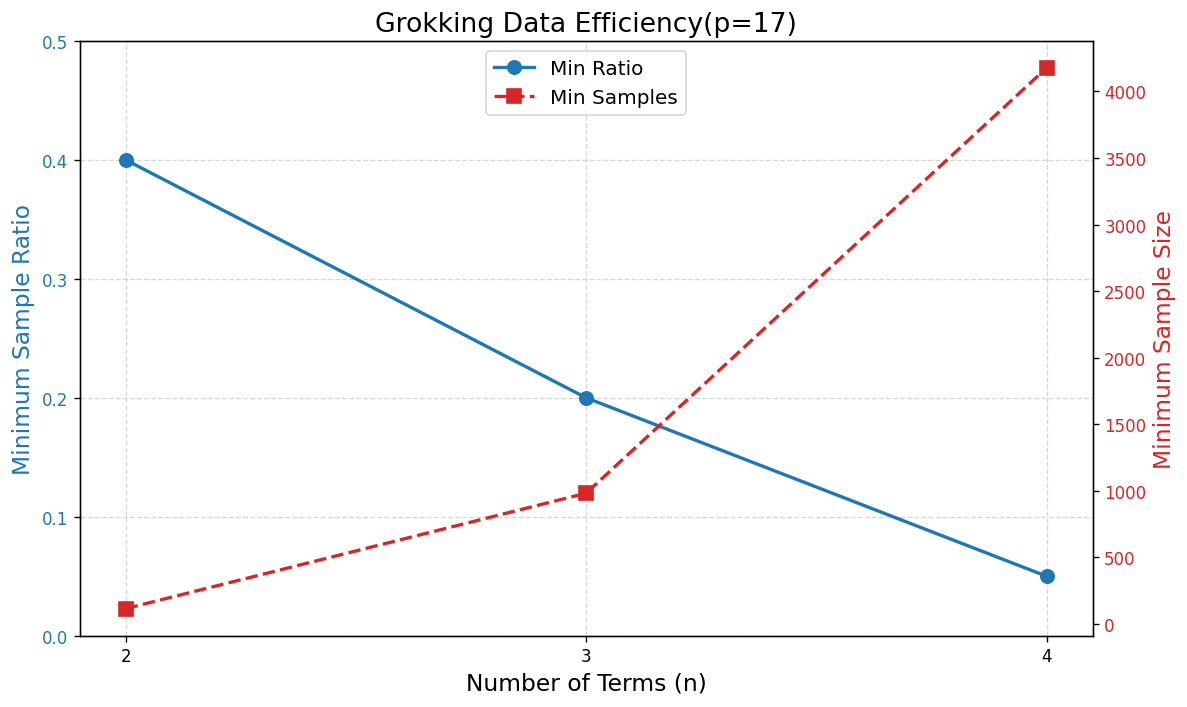

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the previous experiment results
ns = [2, 3, 4]
ratios = [0.4, 0.2, 0.05]
samples = [115, 982, 4176]

# Create figure and axis
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=120)


# Plot Sample Ratio (Left Axis)
color = 'tab:blue'
ax1.set_xlabel('Number of Terms (n)', fontsize=14)
ax1.set_ylabel('Minimum Sample Ratio', color=color, fontsize=14)
ax1.plot(ns, ratios, color=color, marker='o', linestyle='-', linewidth=2, markersize=8, label='Min Ratio')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 0.5)
ax1.set_xticks(ns)
ax1.grid(True, linestyle='--', alpha=0.5)

# Create a second y-axis for Sample Size
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Minimum Sample Size', color=color, fontsize=14)  
ax2.plot(ns, samples, color=color, marker='s', linestyle='--', linewidth=2, markersize=8, label='Min Samples')
ax2.tick_params(axis='y', labelcolor=color)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', fontsize=12)

plt.title("Grokking Data Efficiency(p=17)", fontsize=16)
plt.tight_layout()

# Save and show
plt.savefig('grokking_dual_curves.png')
print("Plot saved to grokking_dual_curves.png")